# Pulse of Prevention: Heart Health Data Analysis

### Python, Pandas, Matplotlib & Seaborn

**Objective:**
Analyze patient health data to identify factors associated with heart disease, understand high-risk patient profiles, and generate data-driven insights that can support preventive healthcare strategies.

**Dataset:** Heart Disease Dataset

**Tools Used:**

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* SciPy
* Scikit-learn


## 1. Business Understanding

### Business Problem

HealthPulse Analytics wants to use patient data to better understand the factors associated with heart disease.

The analysis will focus on patient demographics, clinical measurements, medical history, and heart disease outcomes.

### Key Objectives

1. Understand the structure and quality of the dataset.
2. Analyze patient demographics and clinical measurements.
3. Identify patterns associated with heart disease.
4. Compare patients with and without heart disease.
5. Identify important risk indicators.
6. Develop a profile of higher-risk patients.
7. Build a logistic regression model to predict heart disease.
8. Provide data-driven recommendations for preventive healthcare strategies.

### Key Stakeholders

* Management team
* Healthcare providers
* Data analysts
* Patients
* Cardiology research institute
* Healthcare policymakers


In [50]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The heart disease dataset is loaded into a Pandas DataFrame for analysis.


In [51]:
data = pd.read_csv('/content/heart.csv')

In [52]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Initial Dataset Exploration

Before performing any analysis, we first inspect the dataset structure, dimensions, data types, and basic information.


In [53]:
data.shape

(1025, 14)

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## 4. Data Dictionary

| Column     | Description                                    |
| ---------- | ---------------------------------------------- |
| `age`      | Age of the patient                             |
| `sex`      | Sex of the patient (1 = male, 0 = female)      |
| `cp`       | Chest pain type (0–3)                          |
| `trestbps` | Resting blood pressure in mm Hg                |
| `chol`     | Serum cholesterol in mg/dl                     |
| `fbs`      | Fasting blood sugar >120 mg/dl                 |
| `restecg`  | Resting electrocardiographic result            |
| `thalach`  | Maximum heart rate achieved                    |
| `exang`    | Exercise-induced angina                        |
| `oldpeak`  | ST depression induced by exercise              |
| `slope`    | Slope of the peak exercise ST segment          |
| `ca`       | Number of major vessels colored by fluoroscopy |
| `thal`     | Thalassemia category                           |
| `target`   | Presence of heart disease (1 = yes, 0 = no)    |


In [55]:
# Check missing values

data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [56]:
# Check duplicate records

data.duplicated().sum()

np.int64(723)

In [57]:
data.drop_duplicates().shape

(302, 14)

**Interpretation**

Our dataset contains:

1,025 total rows → 723 duplicate rows → 302 unique records

This means we should remove duplicates before continuing with our analysis.

## 5. Data Cleaning

### Duplicate Records

The original dataset contains duplicate records. Since duplicate observations can give repeated patients disproportionate influence over descriptive statistics and machine-learning results, exact duplicate rows will be removed before further analysis.


In [58]:
# Remove duplicate records

data = data.drop_duplicates().reset_index(drop=True)

In [59]:
data.shape

(302, 14)

In [60]:
data.duplicated().sum()

np.int64(0)

# Validate Data Types & Categorical Values

In [61]:
data.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [62]:
for col in data.columns:
    print(f"\n{col}:")
    print(sorted(data[col].unique()))


age:
[np.int64(29), np.int64(34), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77)]

sex:
[np.int64(0), np.int64(1)]

cp:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

trestbps:
[np.int64(94), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(110), np.int64(112), np.int64(114), np.int64(115), np.int64(117), np.int64(118), np.int64(120), np.int64(122), np.int64(123), np.int64(124), np.int64(125), np.int64(126), np.int64(128), np

In [63]:
print("CA value counts:")
print(data["ca"].value_counts().sort_index())

print("\nThal value counts:")
print(data["thal"].value_counts().sort_index())

CA value counts:
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

Thal value counts:
thal
0      2
1     18
2    165
3    117
Name: count, dtype: int64


### Data Validation Finding

During categorical value validation, two values were identified outside the ranges specified in the project data dictionary:

* `ca = 4` appears in 4 records, while the provided dictionary specifies values from 0 to 3.
* `thal = 0` appears in 2 records, while the provided dictionary specifies values from 1 to 3.

These observations will be retained temporarily and investigated further before any records are removed or recoded. This prevents unsupported assumptions from affecting the analysis.


**Data Validation Summary**

In [64]:
validation = pd.DataFrame({
    "Column": data.columns,
    "Data_Type": data.dtypes.astype(str),
    "Unique_Values": data.nunique(),
    "Missing_Values": data.isnull().sum()
})

validation

,Column,Data_Type,Unique_Values,Missing_Values
age,age,int64,41,0
sex,sex,int64,2,0
cp,cp,int64,4,0
trestbps,trestbps,int64,49,0
chol,chol,int64,152,0
fbs,fbs,int64,2,0
restecg,restecg,int64,3,0
thalach,thalach,int64,91,0
exang,exang,int64,2,0
oldpeak,oldpeak,float64,40,0


In [65]:
#Descriptive Statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [66]:
data["target"].value_counts()

,count
target,
1,164
0,138


# **Identify Outlier**

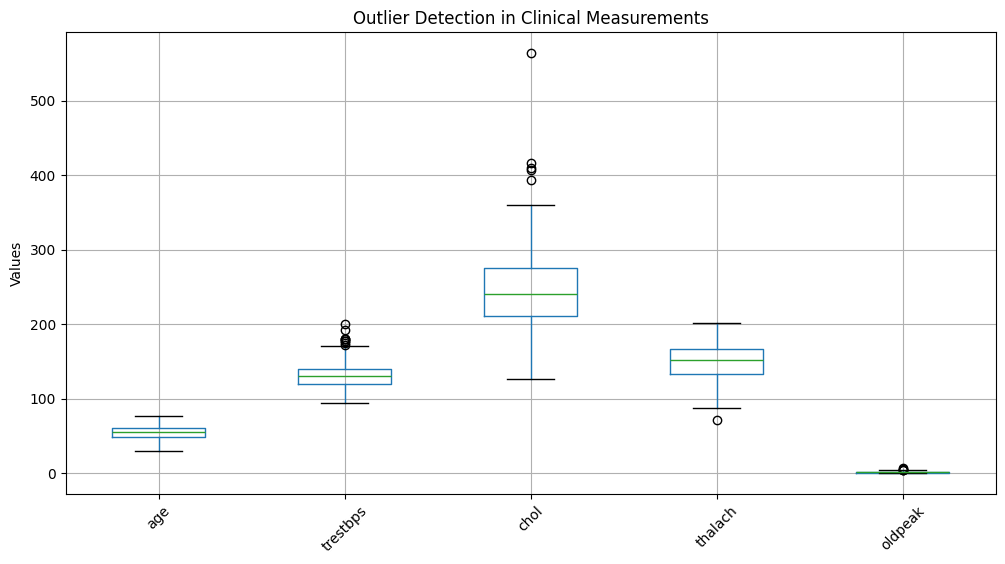

In [67]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(12, 6))
data[numerical_cols].boxplot()
plt.title('Outlier Detection in Clinical Measurements')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

### **Insight**

* **Age:** A few higher-age observations appear, but there are no major extreme outliers.
* **Resting BP (`trestbps`):** Several higher values are visible beyond the upper whisker, indicating some potential outliers.
* **Cholesterol (`chol`):** This shows the **most noticeable outliers**, including several very high cholesterol values.
* **Maximum heart rate (`thalach`):** One or more unusually low values appear as potential outliers.
* **Oldpeak:** Several higher values are outside the upper whisker.

**Decision:** These observations should **not be automatically removed**, because they may represent genuine patient measurements. For this healthcare dataset, we should retain them unless there is evidence that they are data-entry errors.


# **Normalization**

In [68]:
from sklearn.preprocessing import StandardScaler

clinical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()

data_normalized = data.copy()
data_normalized[clinical_cols] = scaler.fit_transform(data[clinical_cols])

data_normalized[clinical_cols].head()

,age,trestbps,chol,thalach,oldpeak
0,-0.267966,-0.376556,-0.667728,0.806035,-0.037124
1,-0.157260,0.478910,-0.841918,0.237495,1.773958
2,1.724733,0.764066,-1.403197,-1.074521,1.342748
3,0.728383,0.935159,-0.841918,0.499898,-0.899544
4,0.839089,0.364848,0.919336,-1.905464,0.739054


### **Insight**

* The clinical measurements have been successfully **standardized** using StandardScaler.
* The normalized values are now centered around **0**, with values representing how far each observation is from the feature's mean in standard-deviation units.
* For example, the first patient's `age` is approximately **0.27 standard deviations below the mean**, while their `thalach` is approximately **0.81 standard deviations above the mean**.
* This puts variables with very different units and scales—such as cholesterol, blood pressure, and heart rate—onto a **comparable scale**.
* We retained the original `data` separately, so the original clinical values remain available for interpretation.


# **Basic Questions**

**1. What is the average age of patients in the dataset?**

In [69]:
average_age = data["age"].mean()
print(f"Average age of patients: {average_age:.2f} years")

Average age of patients: 54.42 years


### **Insight**

The average age of patients in the dataset is approximately **54.42 years**. This indicates that the dataset primarily represents middle-aged and older adults, making age an important demographic variable to examine when investigating heart-disease patterns.


**2. What is the gender distribution of the patients?**

In [70]:
#Gender Counts

gender_counts = data["sex"].map({
    0: "Female",
    1: "Male"
}).value_counts()

gender_counts

,count
sex,
Male,206
Female,96


In [71]:
#Gender Percentage

gender_percentage = (
    data["sex"]
    .map({0: "Female", 1: "Male"})
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender_percentage

,proportion
sex,
Male,68.21
Female,31.79


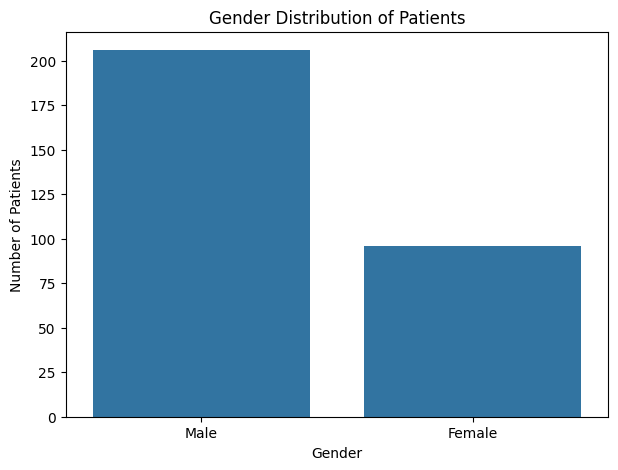

In [72]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=data["sex"].map({0: "Female", 1: "Male"})
)

plt.title("Gender Distribution of Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

### **Insight**

The dataset contains a higher proportion of male patients than female patients. This gender distribution should be considered when interpreting patterns in heart-disease outcomes, because differences in representation can influence comparisons between the two groups.


**3. What is the average resting blood pressure of patients?**

In [73]:
average_bp = data['trestbps'].mean()
print(f"Average resting blood pressure: {average_bp:.2f} mm Hg")

Average resting blood pressure: 131.60 mm Hg


### **Insight**

The average resting blood pressure of patients is approximately **131.60 mm Hg**, indicating that elevated blood pressure is present in the dataset and should be considered when assessing cardiovascular risk and planning preventive interventions.


**4. How many patients have fasting blood sugar levels higher than 120 mg/dl?**

In [74]:
high_fbs = data['fbs'].sum()
print(f"Patients with fasting blood sugar > 120 mg/dl: {high_fbs}")

Patients with fasting blood sugar > 120 mg/dl: 45


### **Insight**

**45 patients** have fasting blood sugar levels above **120 mg/dl**, representing approximately **14.9%** of the dataset. This group can be considered for targeted dietary and lifestyle recommendations as part of preventive heart-health initiatives.


**5. What are the different types of chest pain recorded in the dataset?**

In [75]:
data['cp'].unique()

array([0, 1, 2, 3])

### **Insight**

The dataset contains **four different chest pain types**, coded as **0, 1, 2, and 3**. This indicates that patients in the dataset experience a range of chest pain patterns, which can be further analyzed to understand their relationship with heart disease.


**6. What is the maximum heart rate achieved by patients?**

In [76]:
data['thalach'].max()

202

### **Insight**

The maximum heart rate achieved by patients in the dataset is **202 beats per minute**. This indicates that the dataset includes patients who reached a relatively high maximum heart rate during examination, which can be useful when analyzing cardiovascular fitness and heart disease patterns.


**7. What percentage of patients experience exercise-induced angina?**

In [77]:
data['exang'].mean() * 100

np.float64(32.78145695364238)

### **Insight**

Approximately **32.78% of patients** have exercise-induced angina. This indicates that nearly **one-third of the patients** experience angina during exercise, making it an important factor to consider when assessing cardiovascular health and heart disease patterns.


**8. What is the average cholesterol level in the dataset?**

In [78]:
data['chol'].mean()

np.float64(246.5)

### **Insight**

The average cholesterol level of patients in the dataset is **246.5 mg/dl**. This provides a useful baseline for evaluating cholesterol levels across different patient groups and examining its relationship with heart disease.


**9. How many patients have a resting electrocardiographic result of 2?**

In [79]:
data['restecg'].value_counts()[2]

np.int64(4)

### **Insight**

Only **4 patients** have a resting ECG result of **2**. This represents a **small proportion of the dataset**, indicating that this particular ECG category is relatively uncommon among the patients analyzed.


**10. What is the distribution of the number of major vessels colored by fluoroscopy?**

In [80]:
data['ca'].value_counts()

,count
ca,
0,175
1,65
2,38
3,20
4,4


### **Insight**

The majority of patients (**175**) have **0 major vessels** colored by fluoroscopy, followed by **65 patients with 1 vessel**, **38 with 2 vessels**, and **20 with 3 vessels**.

There are also **4 records with a value of 4**, even though the project data dictionary specifies `ca` as ranging from **0–3**. This anomaly should be documented and investigated rather than silently removed or changed.


# **Medium Questions**

**1. What is the correlation between age and cholesterol levels?**

In [81]:
data[['age', 'chol']].corr()

,age,chol
age,1.000000,0.207216
chol,0.207216,1.000000


### **Insight**

The correlation between **age and cholesterol levels is 0.207**, indicating a **weak positive relationship**. This suggests that cholesterol levels tend to increase slightly as age increases, but the relationship is not strong.


**2. What is the distribution of chest pain types across different age groups?**

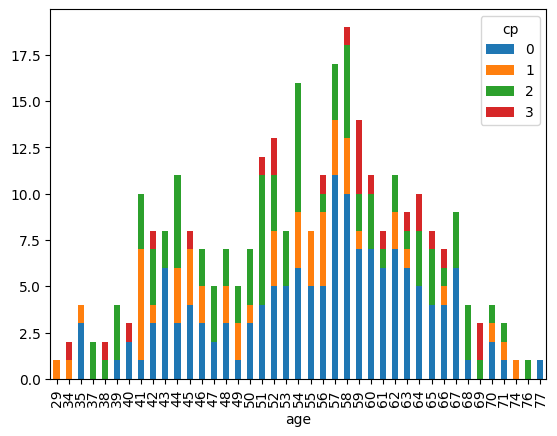

In [82]:
data.groupby('age')['cp'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.show()

### **Insight**

Chest pain types **0, 1, 2, and 3** are observed across the different age groups. The distribution is more concentrated among patients in the **middle-age range, particularly around 50–60 years**, where chest pain types **0 and 2** appear most frequently.

This suggests that chest pain patterns vary across age groups and can be useful for **age-specific assessment of cardiovascular conditions**.


**3. How does maximum heart rate vary with exercise-induced angina?**

In [83]:
data.groupby('exang')['thalach'].mean()

,thalach
exang,
0,155.596059
1,137.212121


### **Insight**

Patients **without exercise-induced angina (exang = 0)** have an average maximum heart rate of **155.60 bpm**, compared with **137.21 bpm** for patients **with exercise-induced angina (exang = 1)**.

This shows a **noticeable difference in maximum heart rate**, with patients experiencing exercise-induced angina achieving lower maximum heart rates on average.


**4. Is there a significant difference in resting blood pressure between male and female patients?**

In [84]:
data.groupby('sex')['trestbps'].mean()

,trestbps
sex,
0,133.083333
1,130.912621


### **Insight**

Female patients (**sex = 0**) have an average resting blood pressure of **133.08 mm Hg**, compared with **130.91 mm Hg** for male patients (**sex = 1**).

The difference is relatively small, with females showing a slightly higher average resting blood pressure. However, **this comparison alone does not establish a statistically significant difference**; a statistical test such as a t-test would be needed to confirm significance.


**5. What is the relationship between fasting blood sugar levels and the presence of heart disease?**

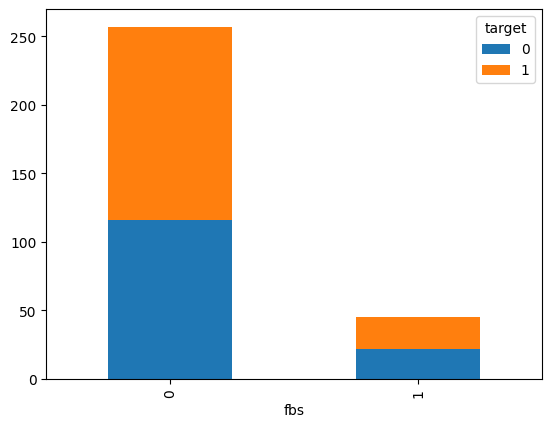

In [85]:
pd.crosstab(data['fbs'], data['target']).plot(kind='bar', stacked=True)
plt.show()

### **Insight**

* The majority of patients have **fasting blood sugar ≤120 mg/dl (fbs = 0)**, and this group also contains most of the heart-disease cases (`target = 1`).
* The **fbs = 1** group (>120 mg/dl) is much smaller, with fewer patients both with and without heart disease.
* Based on this dataset, **fasting blood sugar alone does not show a strong visible relationship with heart disease**, since heart-disease cases are present predominantly in the much larger `fbs = 0` group.
* Therefore, **FBS should be considered alongside other risk factors** rather than used as a standalone indicator of heart disease.

**Business impact:** FBS can still support patient risk assessment, but healthcare providers should combine it with factors such as chest pain, exercise-induced angina, maximum heart rate, cholesterol, and blood pressure for a more complete risk profile.


**6. How does the number of major vessels (ca) affect the target variable (heart disease presence)?**

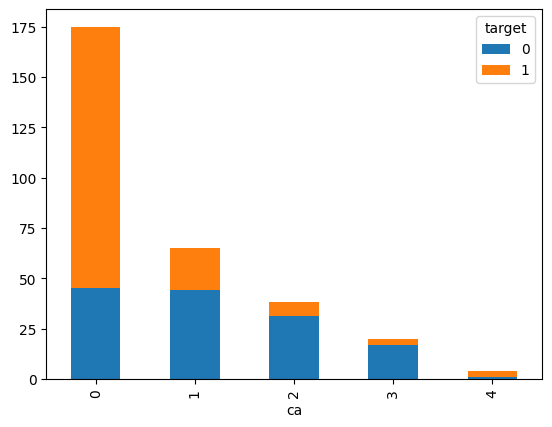

In [86]:
pd.crosstab(data['ca'], data['target']).plot(kind='bar', stacked=True)
plt.show()

### **Insight**

* Patients with **`ca = 0`** form the largest group, and they include a substantial number of heart-disease cases.
* As the number of major vessels increases from **1 to 3**, the proportion of patients with heart disease generally decreases in this dataset.
* The **`ca = 4`** category contains very few observations, so it should not be used for strong conclusions.
* Therefore, in this dataset, **`ca` does not show a simple increasing relationship with heart disease presence** based only on the stacked counts.

**Business impact:** The number of major vessels should be considered as one component of cardiovascular assessment rather than interpreted independently.


**7. What is the average oldpeak value for patients with different types of chest pain?**

In [87]:
data.groupby('cp')['oldpeak'].mean()

,oldpeak
cp,
0,1.383217
1,0.316000
2,0.806977
3,1.391304


### **Insight**

* **CP = 1** has the lowest average `oldpeak` at **0.316**, indicating comparatively lower ST depression.
* **CP = 0** and **CP = 3** have the highest average `oldpeak`, at approximately **1.38** and **1.39**, respectively.
* **CP = 2** has a moderate average `oldpeak` of approximately **0.81**.
* This indicates that **ST depression varies across chest pain types**, with CP 0 and CP 3 showing the highest average values.

**Business impact:** Oldpeak can help healthcare providers assess differences in clinical severity across chest pain categories and support more informed diagnostic and treatment decisions.


**8. Analyze the distribution of thalassemia types (thal) among patients with heart disease.**

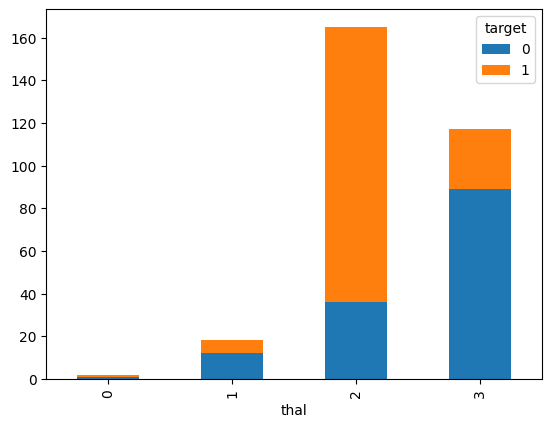

In [88]:
pd.crosstab(data['thal'], data['target']).plot(kind='bar', stacked=True)
plt.show()

### **Insight**

* **Thal = 2** is the most common category and contains the **largest number of heart-disease cases (`target = 1`)**.
* **Thal = 3** is the second-largest category, but it has more patients without heart disease than with it.
* **Thal = 0** has very few observations, so no reliable conclusion should be drawn from it.
* Overall, **thalassemia type 2 shows a stronger association with heart disease in this dataset**, while thal = 3 has a more mixed distribution.

**Business impact:** Thalassemia type can be considered as an important clinical factor when assessing heart-disease risk and may support more focused diagnostic evaluation and specialized care.


**9. What are the most common combinations of risk factors in patients with heart disease?**

In [89]:
data[data['target'] == 1].groupby(
    ['cp', 'fbs', 'exang', 'thal']
).size().reset_index(
    name='counts'
).sort_values(
    by='counts',
    ascending=False
)

,cp,fbs,exang,thal,counts
15,2,0,0,2,41
8,1,0,0,2,30
1,0,0,0,2,23
19,2,1,0,2,10
4,0,0,1,2,6
16,2,0,0,3,6
23,3,0,0,2,5
9,1,0,0,3,4
17,2,0,1,2,4
20,2,1,0,3,3


### **Insight**

* The **most common risk-factor combination** among patients with heart disease is **CP = 2, FBS = 0, Exang = 0, Thal = 2**, occurring in **41 patients**.
* The second most common combination is **CP = 1, FBS = 0, Exang = 0, Thal = 2**, occurring in **30 patients**.
* Another notable combination is **CP = 0, FBS = 0, Exang = 0, Thal = 2**, occurring in **23 patients**.
* Across the most frequent combinations, **FBS = 0, Exang = 0, and Thal = 2** appear repeatedly, while **chest pain type varies**.
* These are **common profiles among heart-disease patients**, not necessarily the highest-risk combinations, because the analysis is based on frequency rather than probability or risk rate.

**Business impact:** Identifying these common profiles can help healthcare providers design more targeted screening and preventive strategies for patients displaying similar combinations of clinical factors.


**10. Perform a pairwise comparison of clinical measurements for patients with and without heart disease.**

In [90]:
print("Patients with heart disease:")
print(data[data['target'] == 1].describe())

print("\nPatients without heart disease:")
print(data[data['target'] == 0].describe())

Patients with heart disease:
              age         sex          cp    trestbps        chol         fbs  \
count  164.000000  164.000000  164.000000  164.000000  164.000000  164.000000   
mean    52.585366    0.560976    1.371951  129.250000  242.640244    0.140244   
std      9.511957    0.497788    0.953878   16.204739   53.456580    0.348303   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     44.750000    0.000000    1.000000  120.000000  208.750000    0.000000   
50%     52.000000    1.000000    2.000000  130.000000  234.500000    0.000000   
75%     59.000000    1.000000    2.000000  140.000000  267.250000    0.000000   
max     76.000000    1.000000    3.000000  180.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  164.000000  164.000000  164.000000  164.000000  164.000000  164.000000   
mean     0.591463  158.378049    0.140244    0.586585    1.591463    0.341463  

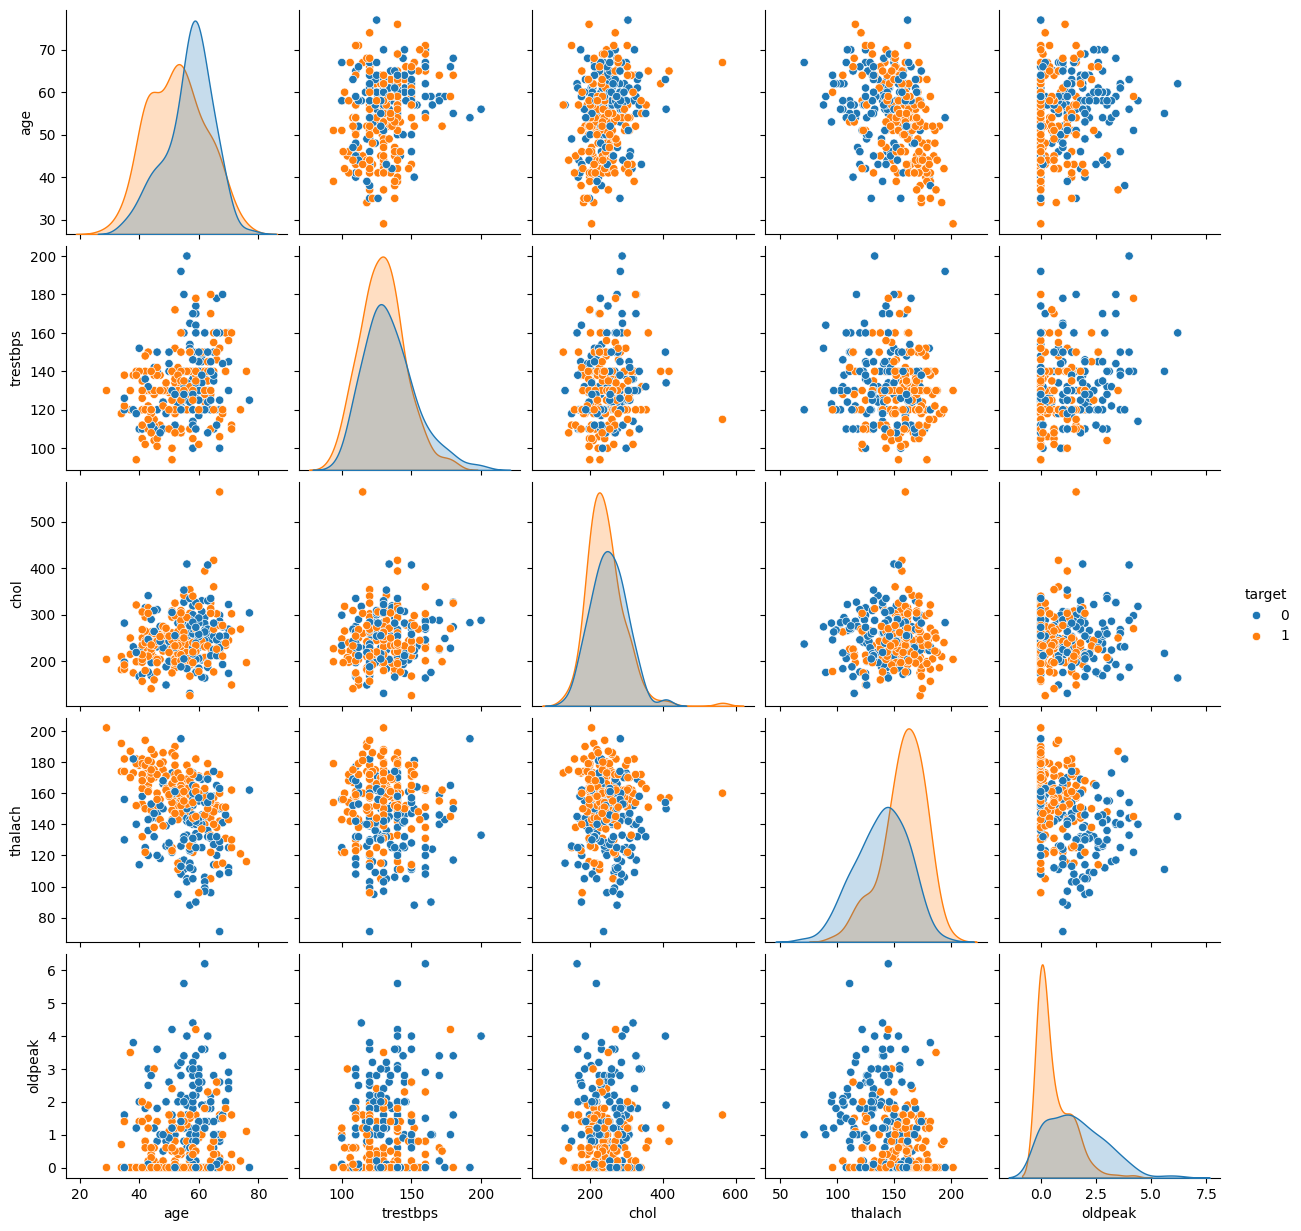

In [91]:
sns.pairplot(
    data,
    hue='target',
    vars=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
)
plt.show()

### **Insight**

* Patients **with heart disease** have a higher average **maximum heart rate (`thalach`)**: **158.38 bpm** vs **139.10 bpm** without heart disease.
* They also have a much lower average **oldpeak**: **0.59** vs **1.59**.
* Heart-disease patients have lower average **age** (**52.59 vs 56.60 years**) and **resting BP** (**129.25 vs 134.40 mm Hg**) in this dataset.
* The average **cholesterol** is slightly lower among heart-disease patients (**242.64 vs 251.09 mg/dl**), so cholesterol does not appear to distinguish the two groups strongly here.
* **Exercise-induced angina (`exang`)** is also notably different: its average is **0.14** among heart-disease patients compared with **0.55** among patients without heart disease.

**Business impact:** The comparison highlights clinical measurements that differ between the two groups and can support more focused risk assessment and personalized patient evaluation.  

# **Advanced Questions**

**1. What is the effect of combining multiple risk factors (age, cholesterol, blood pressure) on the likelihood of heart disease?**

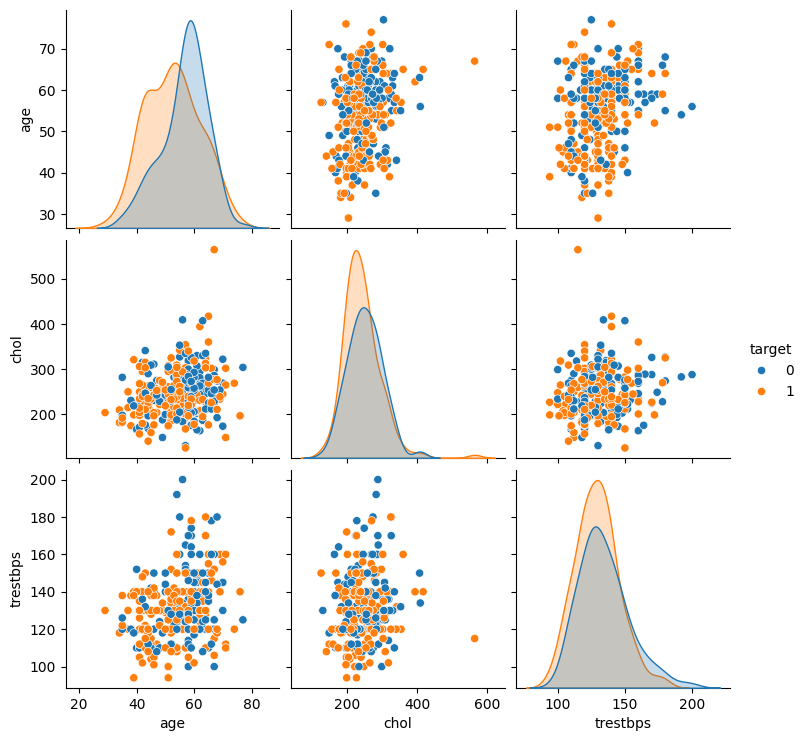

In [92]:
sns.pairplot(
    data,
    hue='target',
    vars=['age', 'chol', 'trestbps']
)
plt.show()

### **Insight**

* The pairplot shows **substantial overlap** between heart-disease and non-heart-disease groups across age, cholesterol, and resting blood pressure.
* **Age:** Heart-disease cases appear somewhat more concentrated around the middle-age range, but age alone does not clearly separate the two target groups.
* **Cholesterol:** There is strong overlap between both groups, suggesting cholesterol alone does not provide a clear distinction.
* **Resting blood pressure:** The distributions also overlap considerably, although the heart-disease group appears somewhat concentrated around the lower-to-mid BP range.
* **Combined effect:** The plot suggests that **age, cholesterol, and resting blood pressure together may contribute to heart-disease likelihood**, but there is no obvious simple boundary separating the two groups.
* Therefore, these variables should be considered **in combination with other clinical factors** rather than used individually to identify high-risk patients.


**2. Which clinical measurement has the strongest correlation with heart disease presence?**

In [93]:
data.corr()['target'].sort_values(ascending=False)

,target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
fbs,-0.026826
chol,-0.081437
trestbps,-0.146269
age,-0.221476
sex,-0.283609


### **Insight**

* **Exercise-induced angina (`exang`)** has the strongest correlation with heart disease at **-0.436**, followed very closely by **chest pain type (`cp`) at +0.432**.
* **Oldpeak** also shows a strong negative correlation (**-0.429**), while **maximum heart rate (`thalach`)** has a positive correlation of **+0.420**.
* Among the clinical measurements specifically, **oldpeak** has the strongest relationship with the target.
* **Cholesterol (−0.081)** and **fasting blood sugar (−0.027)** show very weak correlations with heart disease in this dataset.
* Overall, the analysis suggests that **exercise-related indicators, chest pain, oldpeak, and maximum heart rate are more strongly associated with the heart-disease outcome than cholesterol or fasting blood sugar**.
* These correlations indicate association, **not causation**, and categorical variables such as `cp`, `exang`, and `thal` should be interpreted carefully.


**3. Perform a logistic regression analysis to predict the presence of heart disease using all available features.**

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8032786885245902

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



### **Insight**

* The Logistic Regression model achieved an overall **accuracy of 80.33%** on the test data.
* For patients **with heart disease (target = 1)**, the model achieved **85% recall**, meaning it correctly identified most of the actual heart-disease cases.
* Precision for target = 1 was **80%**, indicating that most patients predicted as having heart disease were actually positive.
* For **target = 0**, recall was **75%**, so the model was slightly less effective at identifying patients without heart disease.
* The **F1-score of 0.82 for target = 1** indicates a good balance between precision and recall for detecting heart-disease cases.
* Overall, the results suggest that the available clinical and demographic features can provide a **reasonably effective basis for predicting heart disease**, although the model should be further validated before being used in real clinical decision-making.

**4. How do the values of the slope of the peak exercise ST segment (slope) vary with different chest pain types?**

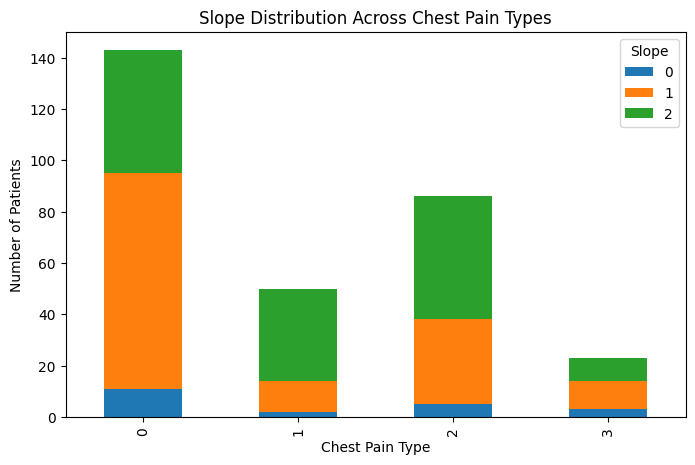

In [95]:
data.groupby('cp')['slope'].value_counts().unstack().plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Slope Distribution Across Chest Pain Types')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.legend(title='Slope')
plt.show()

### **Insight**

* **Chest Pain Type 0** has the highest number of patients and shows a large concentration of **Slope 1**, followed by Slope 2.
* **Chest Pain Type 2** also has a substantial number of patients, with **Slope 2** and Slope 1 being the dominant categories.
* **Chest Pain Types 1 and 3** have fewer patients overall, but Slope 2 remains prominent.
* Overall, **Slope 1 and Slope 2 are the most common slope categories across all chest pain types**, while Slope 0 is relatively uncommon.
* The distribution suggests that **exercise-related ST-segment slope varies across chest pain types**, but the chart alone does not establish that one slope causes or predicts a particular chest pain type.


**5. Analyze the survival rates of patients with different thalassemia types over a period.**

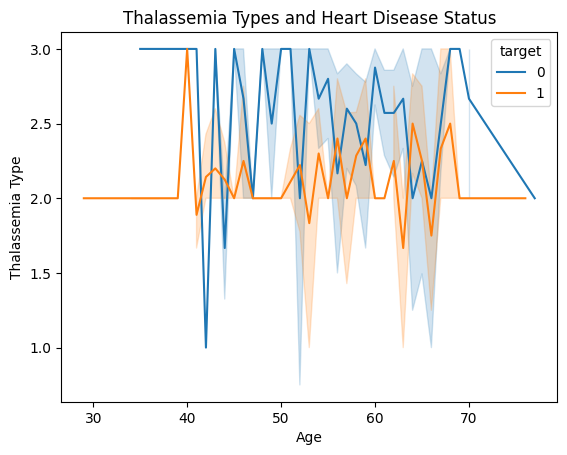

In [96]:
sns.lineplot(x='age', y='thal', hue='target', data=data)
plt.title('Thalassemia Types and Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Thalassemia Type')
plt.show()

### **Insight**

* The plot shows that **thalassemia types 2 and 3 are the most frequently observed categories** across the age range.
* Both heart disease (`target = 1`) and no-heart-disease (`target = 0`) groups appear across multiple thalassemia types and ages.
* There is **no clear age-based trend** showing that a particular thalassemia type consistently corresponds to heart disease.
* The lines fluctuate considerably because the chart uses individual patient records, so it is better viewed as an **exploratory relationship** rather than a survival analysis.
* Most importantly, this dataset does **not contain survival duration or follow-up information**, so actual survival rates over time cannot be calculated from these data. The analysis should therefore be reported as the **relationship between thalassemia type, age, and heart disease status** rather than survival.


## **High-Risk Patient Profile**

Based on the exploratory analysis, patients with heart disease in this dataset generally show the following characteristics:

- Average age is approximately **52.6 years**.
- **Maximum heart rate (thalach)** is higher on average, at approximately **158 bpm**.
- **Exercise-induced angina (exang)** shows a notable relationship with heart disease status.
- **ST depression (oldpeak)** differs considerably between the two groups, with a much lower average among patients with heart disease.
- **Chest pain type (cp)** shows a relatively strong association with the target outcome.
- **Number of major vessels (ca)** and **thalassemia (thal)** also show notable associations with heart disease.
- Demographic and clinical measurements such as cholesterol and resting blood pressure show considerable overlap between patients with and without heart disease.

**Note:** These characteristics represent patterns observed in this dataset and should not be interpreted as definitive clinical risk criteria or causal relationships.

## **Preventive Measures & Lifestyle Recommendations**

Based on the observed patterns in the dataset, the following preventive measures can be considered:

- **Regular cardiovascular screening:** Monitor blood pressure, cholesterol, heart rate, and other relevant clinical indicators regularly.
- **Heart-healthy lifestyle:** Encourage balanced nutrition, regular physical activity, healthy weight management, and avoidance of smoking and other cardiovascular risk factors.
- **Blood pressure and cholesterol management:** Patients with elevated measurements should receive appropriate monitoring and lifestyle guidance.
- **Exercise-related monitoring:** Since exercise-induced angina and maximum heart rate showed notable associations with the target outcome, exercise-related symptoms and responses should be assessed carefully.
- **Early identification of high-risk profiles:** Combine demographic, clinical, and medical-history factors rather than relying on a single indicator.
- **Personalized preventive care:** Preventive strategies should be adapted according to the patient's overall risk profile and clinical assessment.

**Note:** These recommendations are based on patterns identified through exploratory analysis and are not intended to replace professional medical diagnosis or treatment.

## **Areas for Further Medical Research**

The analysis highlights several areas that could be explored further:

- **Exercise-induced angina and heart disease:** Investigate the observed association between exercise-induced angina and heart disease outcomes.
- **ST depression (oldpeak):** Further study the relationship between exercise-induced ST depression and cardiovascular risk.
- **Chest pain characteristics:** Examine how different chest pain types are associated with heart disease and other clinical indicators.
- **Major vessels and thalassemia:** Investigate the relationships between the number of major vessels, thalassemia type, and heart disease outcomes.
- **Combined risk factors:** Study how combinations of demographic, clinical, and medical-history factors influence heart disease risk.
- **Larger and longitudinal datasets:** Future research could use larger datasets with patient follow-up information to evaluate changes in health outcomes over time.

**Note:** These areas are suggested based on associations observed in this dataset and require further clinical research and validation.

## **Key Findings & Visualization Summary**

### Key Findings

- The cleaned dataset contains **302 unique patient records** after removing duplicate entries.
- The average patient age is **54.42 years**, with males representing approximately **68.2%** of the dataset.
- The average resting blood pressure is approximately **131.60 mm Hg**, while average cholesterol is approximately **246.5 mg/dl**.
- Approximately **32.8%** of patients reported exercise-induced angina.
- **Chest pain type, exercise-induced angina, oldpeak, maximum heart rate, number of major vessels, and thalassemia** showed notable associations with heart disease status.
- Patients with heart disease had a higher average maximum heart rate (**~158 bpm**) compared with patients without heart disease (**~139 bpm**).
- Average oldpeak was substantially different between the groups, at approximately **0.59** for patients with heart disease versus **1.59** for patients without heart disease.
- The logistic regression model achieved approximately **80.3% accuracy**, with an **85% recall for patients with heart disease**.
- The analysis indicates that heart disease is influenced by a combination of demographic, clinical, and medical-history factors rather than a single variable.

### Overall Business Insight

The analysis can help healthcare stakeholders focus preventive screening and patient assessment on combinations of important cardiovascular indicators. However, the findings represent associations within this dataset and should be clinically validated before being used for patient-level decision-making.

## **Conclusion**

This analysis explored demographic, clinical, and medical-history factors associated with heart disease using exploratory data analysis and logistic regression.

The analysis identified several notable patterns involving chest pain type, exercise-induced angina, ST depression, maximum heart rate, number of major vessels, and thalassemia. The comparison of patients with and without heart disease also highlighted differences in several clinical measurements.

The logistic regression model achieved approximately **80.3% accuracy**, with **85% recall for patients with heart disease**, indicating that the model was reasonably effective at identifying positive cases within this dataset.

Overall, the findings demonstrate how data analysis can help identify important patterns and support preventive healthcare strategies. However, the observed relationships are based on this dataset and should be validated using larger and clinically representative datasets before being used for medical decision-making.